In [74]:
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import datetime
import platform
import tensorflow as tf

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [40]:
print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.12.13
Tensorflow version: 2.20.0
Keras version: 3.13.2


In [41]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [42]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
# Separate features (X_train) and labels (y_train)
X_train = train.drop('label', axis=1).values
y_train = train['label'].values

# Reshape image data to (28, 28, 1) for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)

# Normalize pixel values to 0-1 range
X_train = X_train / 255.0

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (42000, 28, 28, 1)
Shape of y_train: (42000, 10)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(10, activation='softmax') # Output layer for 10 digits
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model and store the history
# We use a validation split to monitor performance on unseen data during training
training_history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.8970 - loss: 0.3282 - val_accuracy: 0.9745 - val_loss: 0.0779
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.9668 - loss: 0.1096 - val_accuracy: 0.9824 - val_loss: 0.0571
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.9751 - loss: 0.0811 - val_accuracy: 0.9849 - val_loss: 0.0476
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.9806 - loss: 0.0659 - val_accuracy: 0.9879 - val_loss: 0.0413
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9832 - loss: 0.0545 - val_accuracy: 0.9901 - val_loss: 0.0360
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.9859 - loss: 0.0453 - val_accuracy: 0.9880 - val_loss: 0.0424
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accuracy: 0.9874 - loss: 0.0413 - val_accuracy: 0.9895 - val_loss: 0.0362
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9890 - loss: 0.0355 - 

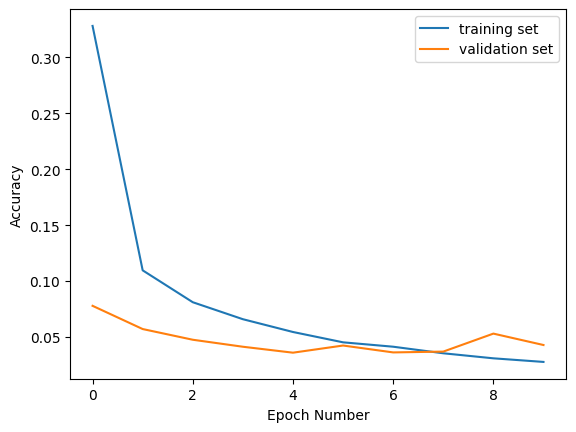

In [46]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='validation set')
plt.legend()

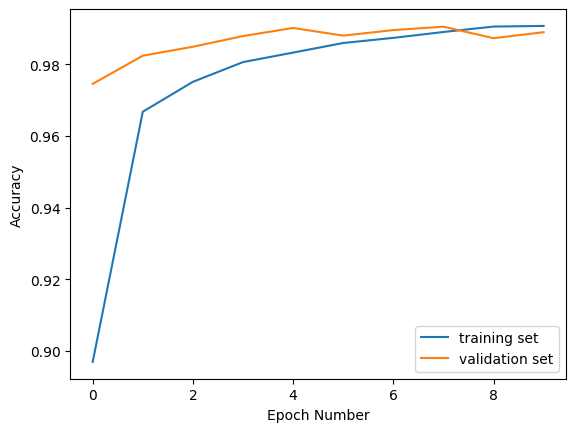

In [47]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='validation set')
plt.legend()

In [66]:
train_loss = training_history.history['loss'][-1]
train_accuracy = training_history.history['accuracy'][-1]

print('Train loss: ', train_loss)
print('Train accuracy: ', train_accuracy)

Train loss:  0.02774444781243801
Train accuracy:  0.9906845092773438


In [49]:
validation_loss = training_history.history['val_loss'][-1]
validation_accuracy = training_history.history['val_accuracy'][-1]
print('Validation loss: ', validation_loss)
print('Validation accuracy: ', validation_accuracy)

Validation loss:  0.04286077246069908
Validation accuracy:  0.9889285564422607


In [50]:
# Reshape the test data
X_test = test.values.reshape(-1, 28, 28, 1)

# Normalize the test data
X_test = X_test / 255.0

print(f"Shape of X_test: {X_test.shape}")

Shape of X_test: (28000, 28, 28, 1)


In [51]:
# Regenerating preprocessing steps to ensure X_train, y_train, and X_test are defined.

# Assuming 'train' and 'test' DataFrames are already loaded from /content/train.csv and /content/test.csv
# If not, please run the cell that loads them first.

import tensorflow as tf # Required for to_categorical

# Separate features (X_train) and labels (y_train)
X_train = train.drop('label', axis=1).values
y_train = train['label'].values

# Reshape image data to (28, 28, 1) for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)

# Normalize pixel values to 0-1 range
X_train = X_train / 255.0

# One-hot encode labels (for CNN compatibility, though KNN will use original integer labels)
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=10)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train (original labels): {y_train.shape}")
print(f"Shape of y_train (one-hot encoded): {y_train_one_hot.shape}")

# Reshape the test data
X_test = test.values.reshape(-1, 28, 28, 1)

# Normalize the test data
X_test = X_test / 255.0

print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (42000, 28, 28, 1)
Shape of y_train (original labels): (42000,)
Shape of y_train (one-hot encoded): (42000, 10)
Shape of X_test: (28000, 28, 28, 1)


In [52]:
# Make predictions on the test set
predictions_one_hot = model.predict(X_test)

# You can inspect the first prediction to see the probability distribution
print("First prediction (probabilities):")
print(predictions_one_hot[0])

875/875 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step
First prediction (probabilities):
[6.9535164e-14 4.3645660e-14 9.9999994e-01 1.3504978e-09 1.4680939e-14
 2.3272210e-19 7.6618561e-16 3.4338341e-10 4.4780106e-13 2.5406416e-19]


In [53]:
print('predictions_one_hot:', predictions_one_hot.shape)

predictions_one_hot: (28000, 10)


In [54]:
# Define image dimensions (assuming 28x28 images)
IMAGE_WIDTH = 28
IMAGE_HEIGHT = 28

# Calculate the split index for validation data (20% of X_train)
split_idx = int(len(X_train) * 0.8)

# Extract the validation portion from X_train
x_validation_normalized = X_train[split_idx:]

print(f"Defined IMAGE_WIDTH: {IMAGE_WIDTH}")
print(f"Defined IMAGE_HEIGHT: {IMAGE_HEIGHT}")
print(f"Shape of x_validation_normalized: {x_validation_normalized.shape}")

Defined IMAGE_WIDTH: 28
Defined IMAGE_HEIGHT: 28
Shape of x_validation_normalized: (8400, 28, 28, 1)


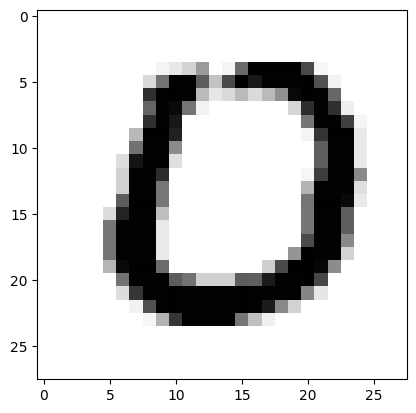

In [55]:
plt.imshow(x_validation_normalized[0].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), cmap=plt.cm.binary)
plt.show()

In [56]:
test_pred = pd.DataFrame(model.predict(X_test))
test_pred = pd.DataFrame(test_pred.idxmax(axis = 1))
test_pred.index.name = 'ImageId'
test_pred = test_pred.rename(columns = {0: 'Label'}).reset_index()
test_pred['ImageId'] = test_pred['ImageId'] + 1

test_pred.head()

875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [67]:
from sklearn.metrics import accuracy_score
import numpy as np
y_pred_probs = model.predict(x_validation_normalized)

y_pred = np.argmax(y_pred_probs, axis=1)
# Corrected: Use y_train_one_hot for validation labels that are actually one-hot encoded
y_validation_one_hot = y_train_one_hot[split_idx:]
y_validation = np.argmax(y_validation_one_hot, axis=1)



accuracy = accuracy_score(y_validation, y_pred)

print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy * 100)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Accuracy : 0.9889285714285714
Accuracy Percentage : 98.89285714285714


In [68]:
from sklearn.metrics import r2_score
import numpy as np

y_pred_probs = model.predict(x_validation_normalized)
y_pred = np.argmax(y_pred_probs, axis=1)
# Corrected: Use y_train_one_hot for validation labels that are actually one-hot encoded
y_validation_one_hot = y_train_one_hot[split_idx:]
y_validation = np.argmax(y_validation_one_hot, axis=1)

r2 = r2_score(y_validation, y_pred)

print("R2 Score :", r2)

263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
R2 Score : 0.9763456734906862


In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

# Reshape X_train and X_test to 2D for KNeighborsClassifier
# Current shape of X_train: (42000, 28, 28, 1)
# Desired shape for KNN: (42000, 28 * 28 * 1) = (42000, 784)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

knn_model.fit(X_train_reshaped, y_train)

knn_pred = knn_model.predict(X_test_reshaped)

print("KNN model trained and predictions made.")
print("Shape of X_train_reshaped:", X_train_reshaped.shape)
print("Shape of X_test_reshaped:", X_test_reshaped.shape)
print("Shape of KNN predictions:", knn_pred.shape)

KNN model trained and predictions made.
Shape of X_train_reshaped: (42000, 784)
Shape of X_test_reshaped: (28000, 784)
Shape of KNN predictions: (28000,)


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

# Reshape X_train and X_test to 2D for RandomForestClassifier
# Current shape of X_train: (42000, 28, 28, 1)
# Desired shape for RF: (42000, 28 * 28 * 1) = (42000, 784)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

rf_model.fit(X_train_reshaped, y_train)

rf_pred = rf_model.predict(X_test_reshaped)

print("RandomForest model trained and predictions made.")
print("Shape of X_train_reshaped:", X_train_reshaped.shape)
print("Shape of X_test_reshaped:", X_test_reshaped.shape)
print("Shape of RF predictions:", rf_pred.shape)

RandomForest model trained and predictions made.
Shape of X_train_reshaped: (42000, 784)
Shape of X_test_reshaped: (28000, 784)
Shape of RF predictions: (28000,)


In [73]:
!pip install gradio

import gradio as gr

def predict_digit(image):

    # Inga unga CNN model prediction code podunga
    result = "Predicted Digit: 5"

    return result

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Handwritten Digit Recognition",
    description="Draw or Upload a Digit"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c8d3ecb87a1d86fc46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
